In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os
os.environ["KAGGLEHUB_CACHE"] = "/Volumes/SecureSSD/Projects/LearningML/kaggle"

In [2]:
path = kagglehub.dataset_download("ishanshrivastava28/superstore-sales")

In [3]:
df = pd.read_csv(path+'/'+'Superstore.csv', encoding='latin1')

In [4]:
profit_df = df.groupby('State')['Profit'].sum().reset_index().sort_values(by = 'Profit', ascending = False).reset_index().head(5)
unique_count = df.groupby('State')['Customer ID'].nunique().reset_index()
profit_df.merge(unique_count, on = 'State')

,index,State,Profit,Customer ID
0,3,California,76381.3871,577
1,30,New York,74038.5486,415
2,45,Washington,33402.6517,224
3,20,Michigan,24463.1876,106
4,44,Virginia,18597.9504,107


In [5]:
highest_order_customer = df.groupby('Customer ID')['Order ID'].nunique().reset_index().sort_values(by = 'Order ID', ascending = False).reset_index(drop = True)['Customer ID'].head(1).to_string(index = False)
df[df['Customer ID'] == highest_order_customer].groupby('Category')['Sales'].sum().reset_index()

,Category,Sales
0,Furniture,2860.0848
1,Office Supplies,1258.1180
2,Technology,1359.8580


In [6]:
pd.pivot_table(df, values = 'Discount', index = ['Ship Mode'], aggfunc='mean').reset_index().merge(df.groupby('Ship Mode')['Profit'].sum().reset_index()).sort_values(by = 'Profit', ascending=False).reset_index(drop = True)

,Ship Mode,Discount,Profit
0,Standard Class,0.160023,164088.7875
1,Second Class,0.138895,57446.6354
2,First Class,0.164610,48969.8399
3,Same Day,0.152394,15891.7589


In [7]:
df['Discount'].corr(df['Profit'])

np.float64(-0.2194874563717679)

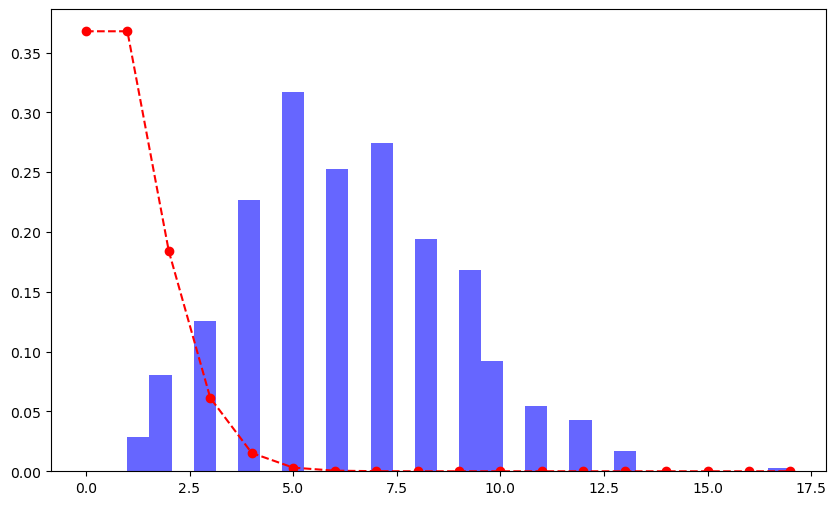

In [8]:
from scipy.stats import poisson
of_df = df.groupby('Customer ID')['Order ID'].nunique()
ok = of_df.mean()
x = np.arange(0, of_df.max() + 1)
pdf = poisson.pmf(x, 1)
plt.figure(figsize=(10, 6))
plt.hist(of_df, bins = 30, density=True, alpha = 0.6, color='b', label = 'orders')
plt.plot(x, pdf, 'r--', marker = 'o', label = 'lambda')

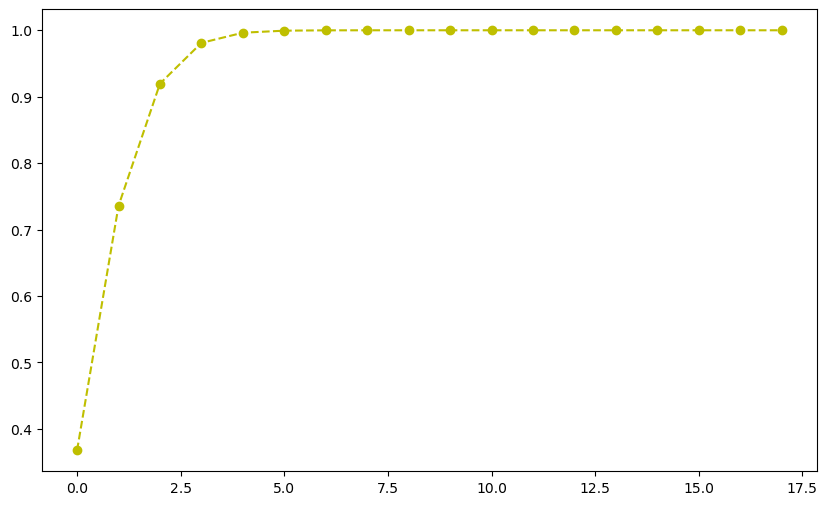

In [9]:
plt.figure(figsize=(10, 6))
plt.plot(x, poisson.cdf(x, 1), 'y--', marker = 'o', label = 'lambda')


In [19]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


/var/folders/cv/q639ql4s6nq9dsgbvxsnywgc0000gn/T/ipykernel_70584/2952664398.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


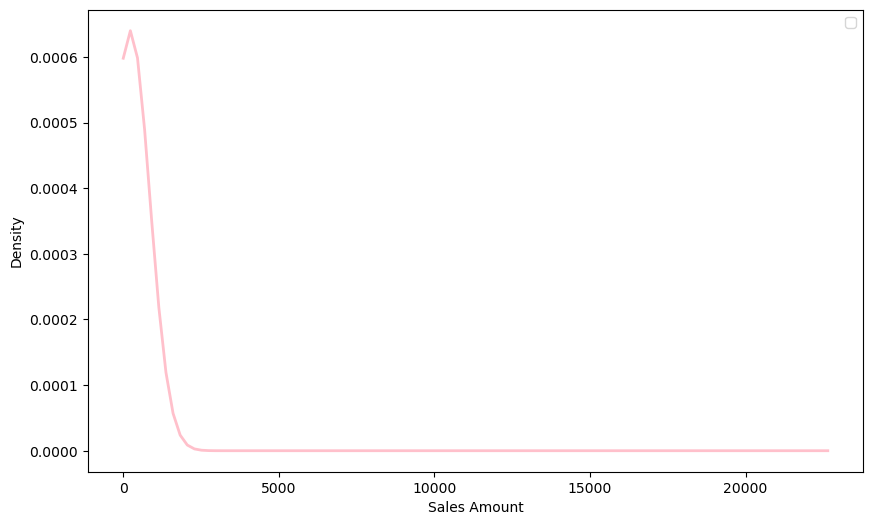

In [71]:
# from scipy.stats import norm
# sales = (df['Sales']).astype(int)
# s = sales.mean()
# dist = norm.pdf(s)
# plt.figure(figsize = (10, 6))
# plt.plot(df['Sales'], color='pink', linewidth=2)
# plt.title(f'Normal Distribution Profit (Average) (p = {s:0.2f})')
# plt.show()
from scipy.stats import norm
plt.figure(figsize=(10, 6))
means = df['Sales'].mean()
stds = df['Sales'].std()
x = np.linspace(df['Sales'].min(), df['Sales'].max(), 100)
pdf = norm.pdf(x, means, stds)
plt.plot(x, pdf, color='pink',linewidth=2)
plt.xlabel("Sales Amount")
plt.ylabel("Density")
plt.legend()
plt.show()

1     0.146280
2     0.134931
3     0.121059
4     0.103405
5     0.089533
6     0.066835
7     0.049180
8     0.042875
9     0.029004
10    0.022699
Name: count, dtype: float64


<Axes: ylabel='count'>

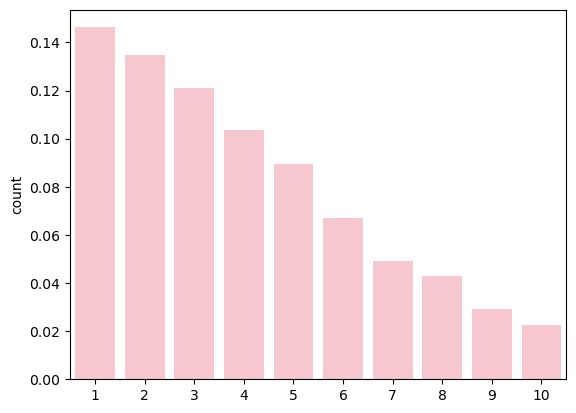

In [82]:
total_order = df.groupby('Customer ID')['Order ID'].nunique().value_counts().reset_index(drop = True).sort_index().sum()
no_of_order = df.groupby('Customer ID')['Order ID'].nunique().value_counts().reset_index(drop = True).sort_index().iloc[1:11]
no_of_order = no_of_order/total_order
print(no_of_order)
sns.barplot(no_of_order, color = 'pink')

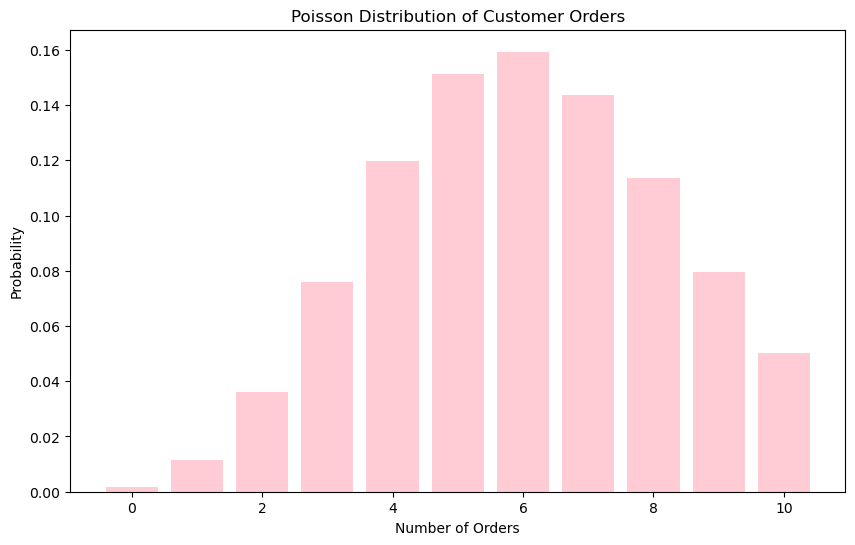

In [81]:
order_counts = df.groupby('Customer ID')['Order ID'].nunique()
poisson_probs = poisson.pmf(np.arange(11), order_counts.mean())
plt.figure(figsize=(10, 6))
plt.bar(np.arange(11), poisson_probs, color='pink', alpha=0.8)
plt.title("Poisson Distribution of Customer Orders")
plt.xlabel("Number of Orders")
plt.ylabel("Probability")
plt.show()

Text(0.5, 1.0, 'Beronulli Distribution Profit (p = 0.81)')

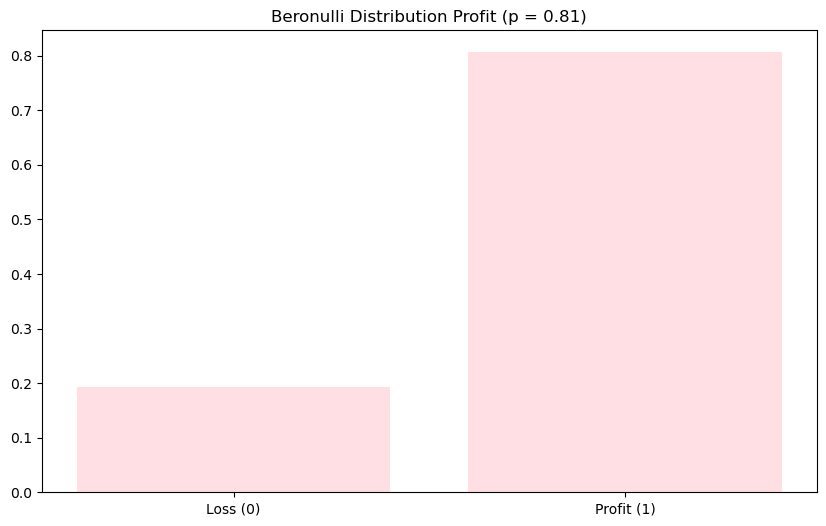

In [78]:
from scipy.stats import bernoulli
profit = (df['Profit'] > 0).astype(int)
p = profit.mean()
x = [0, 1]
pmf = bernoulli.pmf(x, p)
plt.figure(figsize = (10, 6))
plt.bar(x, pmf, tick_label = ["Loss (0)", "Profit (1)"], alpha = 0.5, color = "pink")
plt.title(f'Beronulli Distribution Profit (p = {p:0.2f})')

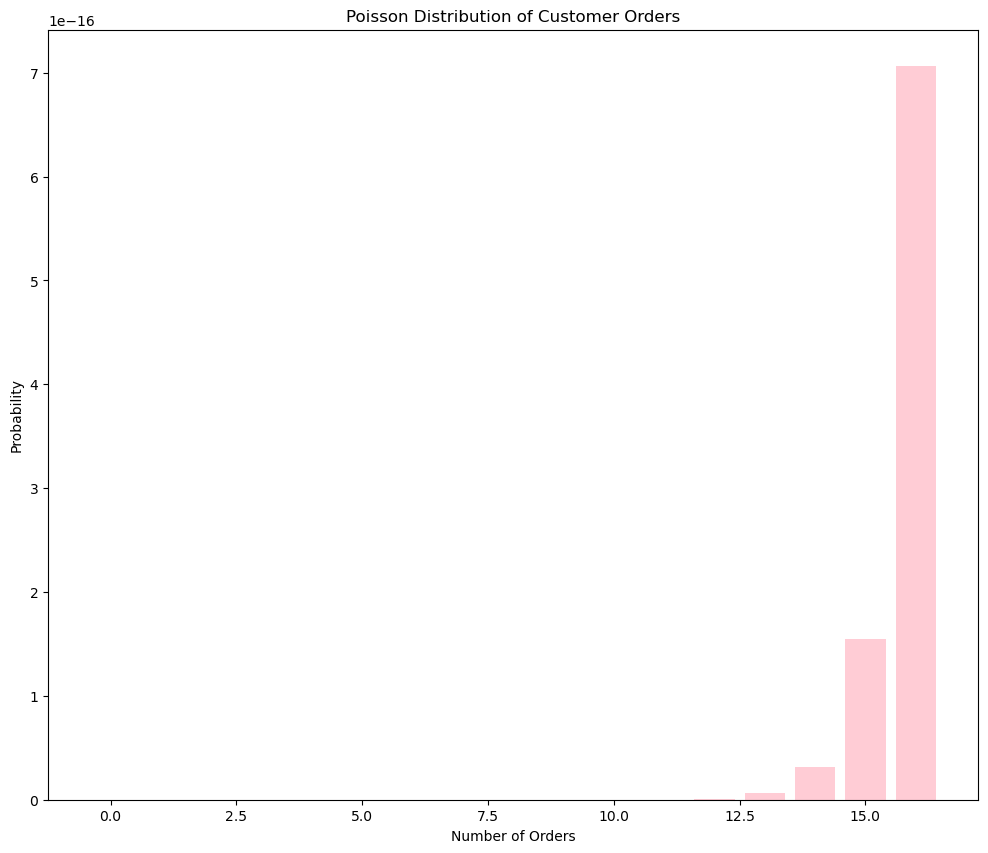

In [97]:
conf=df.groupby('Order Date')['Order ID'].nunique().value_counts().reset_index(drop=True).sort_index(ascending=True)
lambdas=conf.mean()
poisson_probs = poisson.pmf(np.arange(len(conf)),lambdas)
plt.figure(figsize=(12, 10))
plt.bar(np.arange(len(conf)), poisson_probs, color='pink', alpha=0.8)
plt.title("Poisson Distribution of Customer Orders")
plt.xlabel("Number of Orders")
plt.ylabel("Probability")
plt.show()

In [101]:
# df['Order Date'] = pd.to_datetime(df['Order Date'])
# daily_orders = df.groupby('Order Date')['Order ID'].nunique()
# conf = daily_orders.value_counts().sort_index()
# total_days = len(daily_orders)
# probability_of_orders = conf / total_days
# lambdas = daily_orders.mean()
# from scipy.stats import poisson
# max_orders = daily_orders.max()
# x = np.arange(0, max_orders + 1)
# poisson_probs = poisson.pmf(x, lambdas)
# plt.figure(figsize=(12, 8))
# plt.bar(probability_of_orders.index, probability_of_orders.values, color='skyblue', alpha=0.7, label='Empirical')
# plt.plot(x, poisson_probs, 'r-', marker='o', label=f'Poisson ($\lambda$={lambdas:.2f})')
# plt.title('Empirical vs. Poisson Probability Distribution of Daily Orders')
# plt.xlabel('Number of Orders')
# plt.ylabel('Probability')
# plt.legend()
# plt.show()

Text(0.5, 1.0, 'Beronulli Distribution Discount (p = 0.52)')

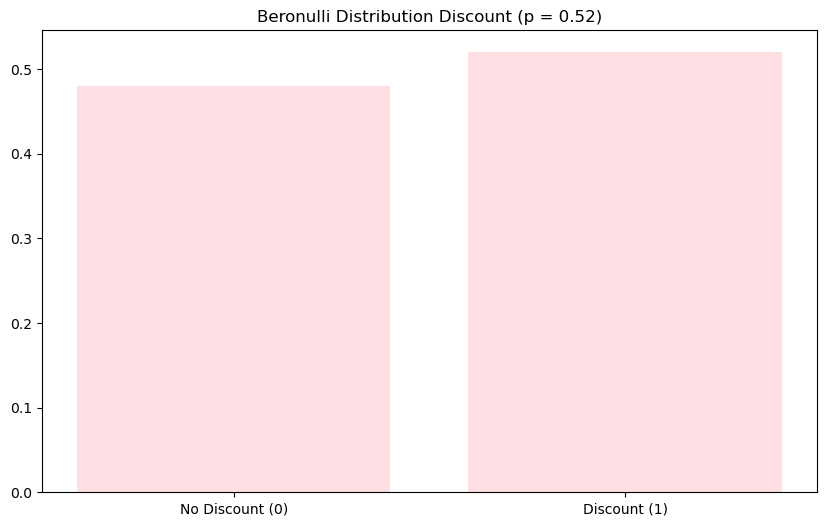

In [88]:
from scipy.stats import bernoulli
discount = (df['Discount'] > 0).astype(int)
d = discount.mean()
x = [0, 1]
pmf = bernoulli.pmf(x, d)
plt.figure(figsize = (10, 6))
plt.bar(x, pmf, tick_label = ["No Discount (0)", "Discount (1)"], alpha = 0.5, color = "pink")
plt.title(f'Beronulli Distribution Discount (p = {d:0.2f})')